# PsychRoute — Fairness-Constrained Bandit Routing for Human–AI Psychiatric Triage

**Companion notebook to:** *PsychRoute: Fairness-Constrained Bandit Routing for Human-AI Psychiatric Triage*  
**Author:** Mohammed Nagi

This notebook is the reference implementation of the system described in the paper. It fine-tunes a MentalBERT classifier on a Bipolar Disorder (BD) vs Major Depressive Disorder (MDD) split of the Mental Disorder Classification dataset, calibrates it per gender, decomposes uncertainty with MC-Dropout, and routes each encounter through a fairness-constrained LinUCB bandit across four governance-anchored actions (`a_model`, `a_support`, `a_escalate`, `a_refuse`).

## Credentials required (set as environment variables before running)

```bash
export HF_TOKEN="hf_..."                 # HuggingFace access token (read-only is fine)
export KAGGLE_USERNAME="your_username"   # optional if ~/.kaggle/kaggle.json exists
export KAGGLE_KEY="your_kaggle_key"      # optional if ~/.kaggle/kaggle.json exists
```

A working `~/.kaggle/kaggle.json` is equivalent to the two Kaggle variables.


## 0. Setup

Install dependencies (run once):
```bash
pip install -q torch transformers huggingface_hub datasets kagglehub \
              shap scikit-learn pandas matplotlib seaborn tqdm fairlearn scipy
```


In [2]:
"""Imports, reproducibility, and global plotting theme."""
import os
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from huggingface_hub import login
from scipy.optimize import minimize_scalar
from scipy.special import expit as sigmoid
from scipy.stats import chi2_contingency, spearmanr
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

import shap
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    false_negative_rate,
    false_positive_rate,
    selection_rate,
)

warnings.filterwarnings("ignore")

# --- Reproducibility ------------------------------------------------------- #
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Plotting theme -------------------------------------------------------- #
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
PALETTE = {
    "Model-Alone": "#C00000",
    "Threshold":   "#1F497D",
    "PsychRoute":  "#1A1A2E",
}
C_MA, C_TH, C_PR = PALETTE["Model-Alone"], PALETTE["Threshold"], PALETTE["PsychRoute"]

# --- HuggingFace authentication (token must come from environment) -------- #
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    raise RuntimeError(
        "Set the HF_TOKEN environment variable to a HuggingFace access token "
        "with read permission before running this notebook."
    )
login(token=HF_TOKEN)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("Setup complete.")


Device  : cuda
PyTorch : 2.10.0+cu128
Setup complete.


## 1. Dataset — Mental Disorder Classification (Kaggle)

The Kaggle dataset (Sarkar, 2023) contains Reddit posts labelled across seven mental-health categories. We filter to **Bipolar Disorder (BD)** vs **Major Depressive Disorder (MDD)** — the exact clinical decision the paper targets.

**Demographic limitation, documented:** the Kaggle file carries no patient demographics. We inject synthetic gender and age-group proxies consistent with WHO epidemiological priors so that the fairness mechanism is exercised. These proxies must be replaced with real demographics before any clinical use; the limitation is recorded in the Nutritional Label (§15).


In [3]:
import kagglehub

path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"Downloaded to: {path}")
print(f"Raw shape    : {df_raw.shape}")
df_raw.head(2)


Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Downloaded to: /kaggle/input/sentiment-analysis-for-mental-health
Raw shape    : (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety


In [4]:
"""Filter to BD vs MDD and inject synthetic demographic proxies."""

# Detect column names (the Kaggle file occasionally renames columns).
TEXT_COL = next(c for c in df_raw.columns
                if c.lower() in ("statement", "text", "post", "content", "sentence"))
LABEL_COL = next(c for c in df_raw.columns
                 if c.lower() in ("status", "label", "disorder", "category", "class"))
print(f'Text column: "{TEXT_COL}"  |  Label column: "{LABEL_COL}"')
print("Label distribution:")
print(df_raw[LABEL_COL].value_counts().to_string())

BD_LABELS  = {"Bipolar", "bipolar", "Bipolar Type-1", "Bipolar Type-2", "Bipolar disorder"}
MDD_LABELS = {"Depression", "depression", "MDD", "Major Depressive",
              "Depressive", "major depressive disorder"}

mask = df_raw[LABEL_COL].isin(BD_LABELS | MDD_LABELS)
df = df_raw[mask].copy()
df["label"] = df[LABEL_COL].apply(lambda x: 1 if x in BD_LABELS else 0)
df = (
    df[[TEXT_COL, "label"]]
    .rename(columns={TEXT_COL: "text"})
    .dropna(subset=["text"])
)
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 20].reset_index(drop=True)

print(f"\nFiltered: {len(df):,} samples")
print(f"  BD  (1): {df['label'].sum():,}  ({df['label'].mean():.1%})")
print(f"  MDD (0): {(~df['label'].astype(bool)).sum():,}  ({1 - df['label'].mean():.1%})")

# --- Synthetic demographic proxies ---------------------------------------- #
# Documented limitation; must be replaced before clinical deployment.
rng_demo = np.random.default_rng(SEED)
N = len(df)
df["gender"]    = rng_demo.choice([0, 1], size=N, p=[0.40, 0.60])      # 0 = M, 1 = F
df["age_group"] = rng_demo.choice([0, 1, 2], size=N, p=[0.45, 0.35, 0.20])
print("\nSynthetic demographics injected.")


Text column: "statement"  |  Label column: "status"
Label distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201

Filtered: 18,126 samples
  BD  (1): 2,777  (15.3%)
  MDD (0): 15,349  (84.7%)

Synthetic demographics injected.


## 2. Train / Calibration / Test split

A three-way 60 / 20 / 20 split stratified on the binary BD label. The calibration set is held out from training and is the *only* set used to choose temperatures and uncertainty thresholds — the test set is never touched until §11.


In [5]:
df_tr, df_tmp = train_test_split(
    df, test_size=0.40, random_state=SEED, stratify=df["label"]
)
df_cal, df_te = train_test_split(
    df_tmp, test_size=0.50, random_state=SEED, stratify=df_tmp["label"]
)
for d in (df_tr, df_cal, df_te):
    d.reset_index(drop=True, inplace=True)

y_tr,  y_cal,  y_te  = df_tr["label"].values, df_cal["label"].values, df_te["label"].values
demo_cal             = df_cal[["gender", "age_group"]].values
demo_te              = df_te [["gender", "age_group"]].values
gender_cal           = demo_cal[:, 0]
gender_te            = demo_te [:, 0]

print(f"Train {len(df_tr):,} | Cal {len(df_cal):,} | Test {len(df_te):,}")
print(f"Test BD%: {y_te.mean():.2%}")


Train 10,875 | Cal 3,625 | Test 3,626
Test BD%: 15.33%


## 3. MentalBERT fine-tuning

Architecture: `[CLS] → Dropout(p=0.1) → Linear(768, 1)` on top of `mental/mental-bert-base-uncased` (Ji et al., 2022).

The classifier follows standard PyTorch `train()` / `eval()` semantics. MC-Dropout (Gal & Ghahramani, 2016) is invoked at inference time by calling `get_probs(..., mc_dropout=True)`, which puts the model into `train()` mode so the dropout layer remains stochastic.


In [6]:
MODEL_NAME = "mental/mental-bert-base-uncased"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)


class MentalHealthDataset(Dataset):
    """Tokenise on the fly so we don't need a pre-encoded HF Dataset object."""

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts, self.labels = texts, labels
        self.tok, self.max_len  = tokenizer, max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.float),
        }


class MentalBERTClassifier(nn.Module):
    """MentalBERT backbone + dropout + linear head.

    Set ``model.train()`` for fine-tuning and stochastic inference (MC-Dropout);
    set ``model.eval()`` for deterministic inference.
    """

    def __init__(self, model_name=MODEL_NAME, dropout_rate=0.10, hf_token=None):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name, token=hf_token)
        self.dropout    = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 1)
        nn.init.xavier_uniform_(self.classifier.weight)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]  # [CLS] token
        pooled = self.dropout(pooled)
        return self.classifier(pooled).squeeze(-1)


def get_probs(model, dataloader, mc_dropout=False):
    """Return sigmoid probabilities over a dataloader.

    Parameters
    ----------
    mc_dropout : bool
        If True, keep dropout layers active (``model.train()``) so the forward
        pass is stochastic — required for MC-Dropout uncertainty estimates.
    """
    model.train() if mc_dropout else model.eval()
    probs = []
    with torch.no_grad():
        for batch in dataloader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            p    = torch.sigmoid(model(ids, mask)).cpu().numpy()
            probs.extend(p)
    return np.array(probs)


def get_logits(model, dataloader):
    """Deterministic logits (eval mode) — used by temperature scaling."""
    model.eval()
    out = []
    with torch.no_grad():
        for batch in dataloader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            out.extend(model(ids, mask).cpu().numpy())
    return np.array(out)


# --- Dataloaders ---------------------------------------------------------- #
dl_tr  = DataLoader(
    MentalHealthDataset(df_tr ["text"].tolist(), y_tr,  tokenizer),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
dl_cal = DataLoader(
    MentalHealthDataset(df_cal["text"].tolist(), y_cal, tokenizer),
    batch_size=32, shuffle=False, num_workers=2,
)
dl_te  = DataLoader(
    MentalHealthDataset(df_te ["text"].tolist(), y_te,  tokenizer),
    batch_size=32, shuffle=False, num_workers=2,
)

print(f"Batches — train: {len(dl_tr)} | cal: {len(dl_cal)} | test: {len(dl_te)}")

model = MentalBERTClassifier(dropout_rate=0.10, hf_token=HF_TOKEN).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Parameters: 109,483,009


In [7]:
"""Fine-tune MentalBERT (3 epochs, AdamW, linear warmup + decay)."""
optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(dl_tr) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.06 * total_steps),
    num_training_steps=total_steps,
)
loss_fn = nn.BCEWithLogitsLoss()

train_losses, val_aucs = [], []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(dl_tr, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        optimizer.zero_grad()
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        loss   = loss_fn(model(ids, mask), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    val_p   = get_probs(model, dl_cal)
    val_auc = roc_auc_score(y_cal, val_p)
    train_losses.append(epoch_loss / len(dl_tr))
    val_aucs.append(val_auc)
    print(f"Epoch {epoch + 1} | Loss {train_losses[-1]:.4f} | Val AUC {val_auc:.4f}")

torch.save(model.state_dict(), "mentalbert_bd_mdd.pt")
print("Saved → mentalbert_bd_mdd.pt")

raw_probs_cal = get_probs(model, dl_cal)
raw_probs_te  = get_probs(model, dl_te)

print(f"\nTest AUC      : {roc_auc_score(y_te, raw_probs_te):.4f}")
print(f"Test Accuracy : {accuracy_score(y_te, raw_probs_te >= 0.5):.4f}")
print(f"Test Error    : {1 - accuracy_score(y_te, raw_probs_te >= 0.5):.4f}\n")
print(classification_report(y_te, raw_probs_te >= 0.5, target_names=["MDD", "BD"]))


Epoch 1/3:   0%|          | 0/680 [00:00<?, ?it/s]

Epoch 1 | Loss 0.1450 | Val AUC 0.9951


Epoch 2/3:   0%|          | 0/680 [00:00<?, ?it/s]

Epoch 2 | Loss 0.0556 | Val AUC 0.9959


Epoch 3/3:   0%|          | 0/680 [00:00<?, ?it/s]

Epoch 3 | Loss 0.0206 | Val AUC 0.9964
Saved → mentalbert_bd_mdd.pt

Test AUC      : 0.9955
Test Accuracy : 0.9741
Test Error    : 0.0259

              precision    recall  f1-score   support

         MDD       0.98      0.99      0.98      3070
          BD       0.92      0.91      0.92       556

    accuracy                           0.97      3626
   macro avg       0.95      0.95      0.95      3626
weighted avg       0.97      0.97      0.97      3626



## 4. Per-gender temperature scaling

We learn a separate temperature $T_g$ for each gender group on the calibration set (Guo et al., 2017). Because the two groups have different BD base rates (≈ 13.6 % male, ≈ 16.5 % female), Chouldechova's impossibility (Chouldechova, 2017) implies that within-group calibration and equalised error rates cannot both hold; we prioritise calibration at the prediction level and let the routing policy in §10 close the outcome gap.

**Note on leakage:** temperatures are fit on `gender_cal` and `y_cal` only. The test set is never seen here.


In [8]:
def ece_score(probs, labels, n_bins=15):
    """Expected Calibration Error (uniform binning)."""
    bins = np.linspace(0, 1, n_bins + 1)
    total = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (probs >= lo) & (probs < hi)
        if m.sum() == 0:
            continue
        total += m.sum() * abs(labels[m].mean() - probs[m].mean())
    return total / max(len(probs), 1)


def temperature_scale(logits, labels):
    """Find scalar T minimising NLL on the given (logits, labels)."""
    def nll(T):
        p = np.clip(sigmoid(logits / T), 1e-7, 1 - 1e-7)
        return -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))
    return minimize_scalar(nll, bounds=(0.1, 10.0), method="bounded").x


def calibrate(logits, genders, T_by_gender):
    p = np.zeros(len(logits))
    for g, T in T_by_gender.items():
        m = genders == g
        p[m] = sigmoid(logits[m] / T)
    return p


# Per-gender temperatures, learned on the CAL set only.
logits_cal = get_logits(model, dl_cal)
logits_te  = get_logits(model, dl_te)

T_by_gender = {
    g: temperature_scale(logits_cal[gender_cal == g], y_cal[gender_cal == g])
    for g in (0, 1)
}

cal_probs_cal = calibrate(logits_cal, gender_cal, T_by_gender)
cal_probs_te  = calibrate(logits_te,  gender_te,  T_by_gender)

print(f"Temperatures   M = {T_by_gender[0]:.3f}   F = {T_by_gender[1]:.3f}")
print(f"ECE pre-cal    : {ece_score(raw_probs_te, y_te):.4f}")
print(f"ECE post-cal   : {ece_score(cal_probs_te, y_te):.4f}\n")

print("Chouldechova check (computed on the test set, never used to fit):")
for g, lbl in [(0, "Male"), (1, "Female")]:
    m = gender_te == g
    acc = accuracy_score(y_te[m], cal_probs_te[m] >= 0.5)
    ece = ece_score(cal_probs_te[m], y_te[m])
    fpr = ((cal_probs_te[m] >= 0.5) & (y_te[m] == 0)).sum() / max((y_te[m] == 0).sum(), 1)
    fnr = ((cal_probs_te[m] <  0.5) & (y_te[m] == 1)).sum() / max((y_te[m] == 1).sum(), 1)
    print(f"  {lbl:6s} | BD%={y_te[m].mean():.2f} | acc={acc:.3f} | "
          f"ECE={ece:.4f} | FPR={fpr:.3f} | FNR={fnr:.3f}")
print("Residual FPR/FNR gap is the expected Chouldechova artefact; routing closes it.")


Temperatures   M = 1.946   F = 2.121
ECE pre-cal    : 0.0224
ECE post-cal   : 0.0097

Chouldechova check (computed on the test set, never used to fit):
  Male   | BD%=0.14 | acc=0.976 | ECE=0.0118 | FPR=0.014 | FNR=0.086
  Female | BD%=0.16 | acc=0.973 | ECE=0.0111 | FPR=0.014 | FNR=0.092
Residual FPR/FNR gap is the expected Chouldechova artefact; routing closes it.


## 5. MC-Dropout uncertainty + cost-ratio thresholds

We run $M = 20$ stochastic forward passes through the dropout-active model. Epistemic uncertainty is the *variance across passes* (model ignorance); aleatoric uncertainty is the *mean Bernoulli variance within a pass* (irreducible label noise).

Triage thresholds $\tau_\text{epi}$ and $\tau_\text{ale}$ are derived from calibration-set errors only — the test set is not consulted, including in the safety clip that bounds the implied escalation rate.


In [9]:
def mc_uncertainty(model, dataloader, M=20):
    """M stochastic forward passes → (mean_p, u_epi, u_ale)."""
    passes = np.stack([get_probs(model, dataloader, mc_dropout=True) for _ in range(M)])
    mean_p = passes.mean(0)
    u_epi  = passes.var(0)                       # variance across passes
    u_ale  = (passes * (1 - passes)).mean(0)     # mean Bernoulli variance
    model.eval()
    return mean_p, u_epi, u_ale


print("MC-Dropout on calibration set ...")
mean_p_cal, u_epi_cal, u_ale_cal = mc_uncertainty(model, dl_cal, M=20)
print("MC-Dropout on test set ...")
mean_p_te,  u_epi_te,  u_ale_te  = mc_uncertainty(model, dl_te,  M=20)

# --- Cost-ratio thresholds (derived from the calibration set only) -------- #
BASE_COSTS   = {"a_model": 1.0, "a_support": 3.0, "a_escalate": 8.0, "a_refuse": 5.0}
REWARD_SCALE = 20.0
LAMBDA       = 2.0


def cost_ratio_threshold(u_vals, errors, cost_diff):
    """Cost-ratio threshold: τ = Δc / (slope · reward_scale).

    Slope = d(error_rate)/d(uncertainty) estimated on a rolling window of the
    sorted (uncertainty, error) pairs. Falls back to the 75th percentile if
    the slope is non-positive (uncertainty is uninformative about error).
    """
    order = np.argsort(u_vals)
    u_s, e_s = u_vals[order], errors[order]
    win   = max(30, len(u_s) // 20)
    roll  = pd.Series(e_s).rolling(win, min_periods=5).mean().values
    mid   = len(u_s) // 2
    du    = u_s[min(mid + 1, len(u_s) - 1)] - u_s[max(mid - 1, 0)] + 1e-12
    de    = roll[min(mid + 1, len(roll) - 1)] - roll[max(mid - 1, 0)]
    slope = de / du
    if slope <= 0 or np.isnan(slope):
        return float(np.percentile(u_vals, 75))
    tau = cost_diff / (slope * REWARD_SCALE)
    return float(np.clip(tau, np.percentile(u_vals, 50), np.percentile(u_vals, 90)))


cal_errors = ((mean_p_cal >= 0.5).astype(int) != y_cal).astype(float)
TAU_EPI = cost_ratio_threshold(u_epi_cal, cal_errors,
                               BASE_COSTS["a_escalate"] - BASE_COSTS["a_model"])
TAU_ALE = cost_ratio_threshold(u_ale_cal, cal_errors,
                               BASE_COSTS["a_refuse"]   - BASE_COSTS["a_model"])

# Safety clip — measured on the CAL set, NOT the test set, to avoid leakage.
implied_esc_cal = (u_epi_cal > TAU_EPI).mean()
if implied_esc_cal > 0.35:
    TAU_EPI = float(np.percentile(u_epi_cal, 65))
    print(f"[Safety clip] implied escalation on cal = {implied_esc_cal:.1%} > 35%;"
          " τ_epi clamped to 65th percentile of cal-set epistemic uncertainty.")

print(f"τ_epi = {TAU_EPI:.6f}   → test-set escalation {(u_epi_te > TAU_EPI).mean():.1%}")
print(f"τ_ale = {TAU_ALE:.6f}   → test-set refusal    {(u_ale_te > TAU_ALE).mean():.1%}")


MC-Dropout on calibration set ...
MC-Dropout on test set ...
τ_epi = 0.000000   → test-set escalation 26.5%
τ_ale = 0.000224   → test-set refusal    26.3%


## 6. Pre-compute enriched predictions for `a_refuse`

When the policy refuses to act on a case, a clinician supplies an enriched note and the model is queried again. To avoid an inner BERT call inside the simulation loop, we identify high-aleatoric candidates ahead of time and pre-compute their enriched probabilities once.

The "enriched" text in this simulation is the original text concatenated with its first half — a placeholder for the longer structured interview note that would arrive in deployment. This is documented in the paper's limitations.


In [10]:
refuse_candidates = np.where(u_ale_te > TAU_ALE)[0]
print(f"Pre-computing enriched predictions for {len(refuse_candidates)} candidates ...")

texts_te = df_te["text"].tolist()
enriched_texts = [
    texts_te[i] + " " + texts_te[i][: len(texts_te[i]) // 2]
    for i in refuse_candidates
]

ds_enriched = MentalHealthDataset(
    enriched_texts, np.zeros(len(enriched_texts), dtype=int), tokenizer
)
dl_enriched = DataLoader(ds_enriched, batch_size=32, shuffle=False, num_workers=2)
enriched_probs_arr = get_probs(model, dl_enriched)   # deterministic

enriched_prob_map = dict(zip(refuse_candidates.tolist(), enriched_probs_arr.tolist()))
print(f"Pre-computation complete. Coverage: {len(enriched_prob_map):,} samples.")


Pre-computing enriched predictions for 955 candidates ...
Pre-computation complete. Coverage: 955 samples.


## 7. Deployment cost and shadow pricing

Each action carries a base cost; the escalation cost rises monotonically with cumulative escalations as the senior-psychiatrist queue fills (a dual-ascent shadow price). The refusal cost adds a fixed delay penalty $\delta t$ to model the cost of waiting for an enriched assessment.


In [11]:
ACTIONS    = ["a_model", "a_support", "a_escalate", "a_refuse"]
CAPACITY_T = int(0.30 * len(y_te))   # B in the paper


def deployment_cost(action, cum_escalations, delta_t=1.5):
    """Cost function with shadow-priced escalation queue.

        c_escalate(t) = c2 + lambda * min(1, cum_esc / B)
        c_refuse      = c4 + delta_t
    """
    c = BASE_COSTS[action]
    if action == "a_escalate":
        c += LAMBDA * min(1.0, cum_escalations / CAPACITY_T)
    elif action == "a_refuse":
        c += delta_t
    return c


## 8. Human skill model

Expert accuracy starts at $h_0^{\text{exp}} = 0.93$ (senior psychiatrist on the SCID protocol) and drifts as the bandit allocates cases: clinicians get rusty (atrophy rate $\gamma$) when the system over-routes to `a_support`, and recover (practice rate $\beta$) when they review escalated cases directly.


In [12]:
H0_EXPERT  = 0.93
H0_SUPPORT = 0.78


class HumanSkillModel:
    """Time-varying human accuracy under the bandit's action stream.

    Atrophy: h falls when AI exposure dominates (rolling window of a_support).
    Recovery: h rises with direct clinical practice (rolling window of a_escalate).
    """

    def __init__(self, h0_expert=H0_EXPERT, h0_support=H0_SUPPORT,
                 gamma=0.06, beta=0.03, window=100,
                 h_min=0.60, h_max=0.97):
        self.h0e, self.h0s = h0_expert, h0_support
        self.gamma, self.beta = gamma, beta
        self.win   = window
        self.h_min, self.h_max = h_min, h_max
        self.ai_exposed   = []
        self.got_practice = []

    def update(self, action):
        self.ai_exposed.append(1 if action == "a_support" else 0)
        self.got_practice.append(1 if action == "a_escalate" else 0)

    def _adjust(self, h0):
        over = np.mean(self.ai_exposed[-self.win:])   if self.ai_exposed   else 0.0
        prac = np.mean(self.got_practice[-self.win:]) if self.got_practice else 0.0
        return float(np.clip(h0 - self.gamma * over + self.beta * prac,
                             self.h_min, self.h_max))

    def expert_accuracy(self):  return self._adjust(self.h0e)
    def support_accuracy(self): return self._adjust(self.h0s)


## 9. Fairness-constrained LinUCB

A 15-dimensional context vector $\phi(x)$ feeds a LinUCB policy (Li et al., 2010) with a Lagrangian fairness penalty (Rawlsian maximin). Dual variables $\mu_g$ (error parity) and $\nu_g$ (cost parity) are updated by projected subgradient ascent on a rolling window so that the penalty stays responsive to late-horizon drift. A ridge prior $\lambda I$ on each action's design matrix prevents rank deficiency during the cold start.


In [13]:
N_FEAT = 15


def make_feature_vector(s, ep, al):
    """15-d unit-norm context: calibrated score, uncertainties, and interactions."""
    x = np.array([
        s, 1 - s, s ** 2,
        ep, al, ep ** 2, al ** 2, ep * al,
        s * ep, s * al, abs(s - 0.5),
        ep / (al + 1e-8),
        float(ep > 0.01), float(al > 0.05),
        1.0,
    ], dtype=np.float64)
    return x / (np.linalg.norm(x) + 1e-8)


class FairLinUCB:
    """LinUCB + Lagrangian fairness penalties on group error and cost parity.

    Reward signal:
        r(a, x) = (1 - error) - cost / REWARD_SCALE
                  - mu_g * max(0, eps_g_W - eps_bar_W - delta)
                  - nu_g * max(0, rho_g_W - rho_bar_W - delta)

    where eps_g_W and rho_g_W are rolling means over the most recent W
    encounters for group g. Dual variables update by projected subgradient
    ascent on the constraint violations; logs are exposed for inspection.
    """

    def __init__(self, n_feat=N_FEAT, alpha=1.2, delta=0.05,
                 lr_dual=0.005, window=100, ridge=1.0):
        self.d, self.alpha = n_feat, alpha
        self.delta, self.lr = delta, lr_dual
        self.W, self.ridge = window, ridge
        self.groups = [0, 1]

        self.A = {a: np.eye(n_feat) * ridge for a in ACTIONS}
        self.b = {a: np.zeros(n_feat)       for a in ACTIONS}

        self.mu = {g: 0.0 for g in self.groups}
        self.nu = {g: 0.0 for g in self.groups}
        self.group_errors = {g: [] for g in self.groups}
        self.group_costs  = {g: [] for g in self.groups}

        # Transparency logs (one entry per bandit update step)
        self.log_mu = {g: [] for g in self.groups}
        self.log_nu = {g: [] for g in self.groups}
        self.log_violations = []

    # --- helpers ---------------------------------------------------------- #
    def _roll(self, lst):
        recent = lst[-self.W:]
        return float(np.mean(recent)) if recent else 0.0

    def _ucb_score(self, action, phi_x):
        # np.linalg.solve is preferable to np.linalg.inv for stability and speed
        Ainv_phi = np.linalg.solve(self.A[action], phi_x)
        w_hat    = np.linalg.solve(self.A[action], self.b[action])
        exploit  = w_hat @ phi_x
        explore  = self.alpha * np.sqrt(max(0.0, float(phi_x @ Ainv_phi)))
        return exploit + explore

    def _penalty(self, group):
        eps_g = self._roll(self.group_errors[group])
        rho_g = self._roll(self.group_costs [group])
        eps_bar = np.mean([self._roll(self.group_errors[h]) for h in self.groups])
        rho_bar = np.mean([self._roll(self.group_costs [h]) for h in self.groups])
        return (self.mu[group] * max(0.0, eps_g - eps_bar - self.delta) +
                self.nu[group] * max(0.0, rho_g - rho_bar - self.delta))

    # --- policy interface ------------------------------------------------- #
    def select_action(self, phi_x, group, triage=None):
        """Return triage action if set, else argmax (UCB - penalty)."""
        if triage is not None:
            return triage
        pen    = self._penalty(group)
        scores = {a: self._ucb_score(a, phi_x) - pen for a in ACTIONS}
        return max(scores, key=scores.get)

    def update(self, action, phi_x, reward, error, cost, group):
        """Update ridge regression for the chosen action and the duals for the group."""
        self.A[action] += np.outer(phi_x, phi_x)
        self.b[action] += reward * phi_x
        self.group_errors[group].append(float(error))
        self.group_costs [group].append(float(cost))

        eps_g = self._roll(self.group_errors[group])
        rho_g = self._roll(self.group_costs [group])
        eps_bar = np.mean([self._roll(self.group_errors[h]) for h in self.groups])
        rho_bar = np.mean([self._roll(self.group_costs [h]) for h in self.groups])
        eps_v = max(0.0, eps_g - eps_bar - self.delta)
        rho_v = max(0.0, rho_g - rho_bar - self.delta)

        self.mu[group] = max(0.0, self.mu[group] + self.lr * eps_v)
        self.nu[group] = max(0.0, self.nu[group] + self.lr * rho_v)

        self.log_mu[group].append(self.mu[group])
        self.log_nu[group].append(self.nu[group])
        self.log_violations.append({"group": group, "eps_v": eps_v, "rho_v": rho_v})


## 10. Strategy simulation

We compare three strategies on the held-out test set:

- **Model-Alone** — the AI predicts on every case.
- **Threshold** — the AI predicts unless the calibrated score is in the ambiguous band $[0.35, 0.65]$, in which case the case is escalated.
- **PsychRoute** — the full pipeline: triage gate on $(\tau_\text{epi}, \tau_\text{ale})$, FairLinUCB otherwise.

**Regret oracle.** Regret is measured against a fixed-skill oracle ($h = 0.93$) whose predictions are sampled *once* before the simulation loop. This avoids the circularity that arises when the oracle's accuracy itself drifts with the bandit's choices.


In [14]:
def simulate(strategy, y_te, demo_te, cal_probs, u_epi, u_ale,
             enriched_map=None,
             tau_epi=None, tau_ale=None, seed=SEED):
    """Run one strategy through the test set; return per-step record + final bandit."""
    if tau_epi is None: tau_epi = TAU_EPI
    if tau_ale is None: tau_ale = TAU_ALE

    rng    = np.random.default_rng(seed)
    N      = len(y_te)
    bandit = FairLinUCB()
    skill  = HumanSkillModel()

    # Fixed-skill oracle predictions, sampled once (cf. §10 regret note).
    oracle_rng = np.random.default_rng(seed + 1)
    oracle_correct = oracle_rng.random(N) < H0_EXPERT
    oracle_y = np.where(oracle_correct, y_te, 1 - y_te)
    oracle_err = (oracle_y != y_te).astype(int)

    rec = {k: [] for k in
           ["action", "error", "cost", "y_pred", "gender",
            "covered", "regret", "h_t", "u_epi", "u_ale"]}
    cum_esc = 0

    for i in range(N):
        s, ep, al = cal_probs[i], u_epi[i], u_ale[i]
        true_y    = y_te[i]
        gender    = int(demo_te[i, 0])
        phi_x     = make_feature_vector(s, ep, al)

        # --- Action selection ------------------------------------------- #
        if strategy == "model_alone":
            action = "a_model"
        elif strategy == "threshold":
            action = "a_escalate" if 0.35 <= s <= 0.65 else "a_model"
        else:  # psychroute
            triage = None
            if   ep > tau_epi: triage = "a_escalate"
            elif al > tau_ale: triage = "a_refuse"
            action = bandit.select_action(phi_x, gender, triage)

        cost  = deployment_cost(action, cum_esc)
        h_exp = skill.expert_accuracy()
        h_sup = skill.support_accuracy()
        skill.update(action)

        # --- Outcome ---------------------------------------------------- #
        if action == "a_model":
            y_pred, covered, h_t = int(s >= 0.5), 1, 0.0

        elif action == "a_support":
            ai_pred  = int(s >= 0.5)
            hum_pred = true_y if rng.random() < h_sup else 1 - true_y
            # Automation-bias coin: clinician agrees with AI 65% of the time.
            y_pred   = ai_pred if rng.random() < 0.65 else hum_pred
            covered, h_t = 1, h_sup

        elif action == "a_escalate":
            cum_esc += 1
            y_pred   = true_y if rng.random() < h_exp else 1 - true_y
            covered, h_t = 0, h_exp

        else:  # a_refuse
            enrich_s = enriched_map.get(i, s) if enriched_map else s
            y_pred   = int(enrich_s >= 0.5)
            covered, h_t = 1, 0.0

        error  = int(y_pred != true_y)
        reward = 1.0 - error - cost / REWARD_SCALE
        regret = max(0, error - int(oracle_err[i]))

        for k, v in zip(rec.keys(),
                        [action, error, cost, y_pred, gender,
                         covered, regret, h_t, ep, al]):
            rec[k].append(v)

        if strategy == "psychroute":
            bandit.update(action, phi_x, reward, error, cost, gender)

    return {k: np.array(v) for k, v in rec.items()}, bandit


print("Running simulations ...")
res_ma, _         = simulate("model_alone", y_te, demo_te, cal_probs_te,
                              u_epi_te, u_ale_te)
res_th, _         = simulate("threshold",   y_te, demo_te, cal_probs_te,
                              u_epi_te, u_ale_te)
res_pr, bandit_pr = simulate("psychroute",  y_te, demo_te, cal_probs_te,
                              u_epi_te, u_ale_te,
                              enriched_map=enriched_prob_map)

print("\nStrategy summary:")
for nm, res in [("Model-Alone", res_ma), ("Threshold", res_th), ("PsychRoute", res_pr)]:
    print(f"  {nm:14s} "
          f"Err={res['error'].mean():.3f}  "
          f"Esc={(res['action']=='a_escalate').mean():.1%}  "
          f"Sup={(res['action']=='a_support').mean():.1%}  "
          f"Ref={(res['action']=='a_refuse').mean():.1%}  "
          f"Cov={res['covered'].mean():.1%}")


Running simulations ...

Strategy summary:
  Model-Alone    Err=0.026  Esc=0.0%  Sup=0.0%  Ref=0.0%  Cov=100.0%
  Threshold      Err=0.023  Esc=0.7%  Sup=0.0%  Ref=0.0%  Cov=99.3%
  PsychRoute     Err=0.017  Esc=26.5%  Sup=1.4%  Ref=1.1%  Cov=73.5%


## 11. Headline evaluation — three-way complementarity

Complementarity is reported against *both* baselines:
- $\Delta_\text{comp}^\text{AI} = e_\text{system} - e_\text{AI-only}$ — negative means the system beats the AI alone.
- $\Delta_\text{comp}^\text{human} = e_\text{system} - e_\text{human-only}$ — negative means the system beats the human alone.

Genuine complementarity requires both to be negative (Mozannar & Sontag, 2020).


In [15]:
def group_error_gap(res):
    """|error_M − error_F| — scalar."""
    e = {g: res["error"][res["gender"] == g].mean() for g in (0, 1)}
    return abs(e[0] - e[1])


def delta_comp(res, ai_error, human_error):
    sys = res["error"].mean()
    return {"vs_AI": sys - ai_error, "vs_human": sys - human_error, "system": sys}


ai_error    = res_ma["error"].mean()
human_error = 1 - H0_EXPERT

print("=" * 74)
print(f'{"Metric":<32} {"Model-Alone":>12} {"Threshold":>12} {"PsychRoute":>12}')
print("=" * 74)

metrics = {}
for sk, res in [("ma", res_ma), ("th", res_th), ("pr", res_pr)]:
    dc = delta_comp(res, ai_error, human_error)
    metrics[sk] = {
        "error":       res["error"].mean(),
        "escalation":  (res["action"] == "a_escalate").mean(),
        "coverage":    res["covered"].mean(),
        "dc_vs_AI":    dc["vs_AI"],
        "dc_vs_human": dc["vs_human"],
        "group_gap":   group_error_gap(res),
        "avg_cost":    res["cost"].mean(),
        "cum_regret":  res["regret"].sum(),
    }

rows = [
    ("Diagnostic error rate", "error",       "{:.3f}"),
    ("Escalation rate",       "escalation",  "{:.1%}"),
    ("AI coverage",           "coverage",    "{:.1%}"),
    ("Δ_comp vs AI-only",     "dc_vs_AI",    "{:+.3f}"),
    ("Δ_comp vs Human-only",  "dc_vs_human", "{:+.3f}"),
    ("Group error gap Δε",    "group_gap",   "{:.4f}"),
    ("Avg cost / patient",    "avg_cost",    "{:.2f}"),
    ("Cumulative regret",     "cum_regret",  "{:.0f}"),
]
for label, key, fmt in rows:
    vals = [metrics[k][key] for k in ("ma", "th", "pr")]
    print(f"{label:<32}" + "".join(f"{fmt.format(v):>12}" for v in vals))
print("=" * 74)

print("\nComplementarity verdict:")
for nm, sk in [("Model-Alone", "ma"), ("Threshold", "th"), ("PsychRoute", "pr")]:
    va = metrics[sk]["dc_vs_AI"]
    vh = metrics[sk]["dc_vs_human"]
    verdict = "complementary" if va < 0 and vh < 0 else "not complementary"
    print(f"  {nm:14s}  Δ_vs_AI={va:+.3f}  Δ_vs_human={vh:+.3f}  →  {verdict}")

# Persist headline table.
fmt_for_csv = [
    ("error",       "{:.3f}"), ("escalation",  "{:.1%}"),
    ("coverage",    "{:.1%}"), ("dc_vs_AI",    "{:+.3f}"),
    ("dc_vs_human", "{:+.3f}"), ("group_gap",   "{:.4f}"),
    ("avg_cost",    "{:.2f}"), ("cum_regret",  "{:.0f}"),
]
csv_rows = []
for nm, sk in [("Model-Alone", "ma"), ("Threshold", "th"), ("PsychRoute", "pr")]:
    row = {"Strategy": nm}
    for k, fmt in fmt_for_csv:
        row[k] = fmt.format(metrics[sk][k])
    csv_rows.append(row)
pd.DataFrame(csv_rows).to_csv("results.csv", index=False)
print("\nSaved → results.csv")


Metric                            Model-Alone    Threshold   PsychRoute
Diagnostic error rate                  0.026       0.023       0.017
Escalation rate                         0.0%        0.7%       26.5%
AI coverage                           100.0%       99.3%       73.5%
Δ_comp vs AI-only                     +0.000      -0.003      -0.009
Δ_comp vs Human-only                  -0.044      -0.047      -0.053
Group error gap Δε                    0.0029      0.0024      0.0045
Avg cost / patient                      1.00        1.05        3.18
Cumulative regret                         89          78          53

Complementarity verdict:
  Model-Alone     Δ_vs_AI=+0.000  Δ_vs_human=-0.044  →  not complementary
  Threshold       Δ_vs_AI=-0.003  Δ_vs_human=-0.047  →  complementary
  PsychRoute      Δ_vs_AI=-0.009  Δ_vs_human=-0.053  →  complementary

Saved → results.csv


## 12. Fairlearn audit — base model vs PsychRoute system


In [16]:
y_pred_base = (cal_probs_te >= 0.5).astype(int)
y_pred_pr   = res_pr["y_pred"]


def fairlearn_panel(y_true, y_pred, sensitive, name):
    mf = MetricFrame(
        metrics={
            "selection_rate":      selection_rate,
            "false_positive_rate": false_positive_rate,
            "false_negative_rate": false_negative_rate,
            "accuracy":            lambda yt, yp: (yt == yp).mean(),
        },
        y_true=y_true, y_pred=y_pred, sensitive_features=sensitive,
    )
    print(f"── {name} ─────────────────────────────────────────────────────")
    print(mf.by_group.rename(index={0: "Male", 1: "Female"}).round(4).to_string())
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eod = equalized_odds_difference   (y_true, y_pred, sensitive_features=sensitive)
    sr  = mf.by_group["selection_rate"]
    di  = sr.min() / sr.max()
    di_flag = "passes 80% rule" if di >= 0.80 else "fails 80% rule"
    print(f"\nDemographic Parity Difference : {dpd:+.4f}")
    print(f"Equalized Odds Difference     : {eod:+.4f}")
    print(f"Disparate Impact Ratio        : {di:.4f}  ({di_flag})\n")
    return mf, dpd, eod, di


mf_base, dpd_base, eod_base, di_base = fairlearn_panel(
    y_te, y_pred_base, gender_te, "Base Model Fairness Audit"
)
mf_pr, dpd_pr, eod_pr, di_pr = fairlearn_panel(
    y_te, y_pred_pr,   gender_te, "PsychRoute System Fairness Audit"
)


── Base Model Fairness Audit ─────────────────────────────────────────────────────
                     selection_rate  false_positive_rate  false_negative_rate  accuracy
sensitive_feature_0                                                                    
Male                         0.1369               0.0144               0.0863    0.9758
Female                       0.1615               0.0143               0.0919    0.9729

Demographic Parity Difference : +0.0245
Equalized Odds Difference     : +0.0056
Disparate Impact Ratio        : 0.8480  (passes 80% rule)

── PsychRoute System Fairness Audit ─────────────────────────────────────────────────────
                     selection_rate  false_positive_rate  false_negative_rate  accuracy
sensitive_feature_0                                                                    
Male                         0.1432               0.0120               0.0254    0.9862
Female                       0.1601               0.0082               

In [17]:
# --- Chouldechova quantification -------------------------------------------
print("── Chouldechova impossibility (quantified) ──────────────────────")
rows_ch = []
for g, lbl in [(0, "Male"), (1, "Female")]:
    m = gender_te == g
    rows_ch.append({
        "Group":         lbl,
        "BD prevalence": y_te[m].mean(),
        "ECE":           ece_score(cal_probs_te[m], y_te[m]),
        "FPR":           ((y_pred_base[m] == 1) & (y_te[m] == 0)).sum() /
                          max((y_te[m] == 0).sum(), 1),
        "FNR":           ((y_pred_base[m] == 0) & (y_te[m] == 1)).sum() /
                          max((y_te[m] == 1).sum(), 1),
    })
ch_df = pd.DataFrame(rows_ch).set_index("Group").round(4)
print(ch_df.to_string())

prev_gap = abs(rows_ch[0]["BD prevalence"] - rows_ch[1]["BD prevalence"])
fnr_gap  = abs(rows_ch[0]["FNR"] - rows_ch[1]["FNR"])
fpr_gap  = abs(rows_ch[0]["FPR"] - rows_ch[1]["FPR"])
print(f"\nBD prevalence gap : {prev_gap:.4f}")
print(f"FNR gap            : {fnr_gap:.4f}  (cannot reach 0 while staying calibrated)")
print(f"FPR gap            : {fpr_gap:.4f}  (cannot reach 0 while staying calibrated)")
print("\nCalibration is prioritised at the prediction level; the routing")
print("policy corrects disparate OUTCOMES at decision time.")


── Chouldechova impossibility (quantified) ──────────────────────
        BD prevalence     ECE     FPR     FNR
Group                                        
Male           0.1362  0.0118  0.0144  0.0863
Female         0.1647  0.0111  0.0143  0.0919

BD prevalence gap : 0.0284
FNR gap            : 0.0056  (cannot reach 0 while staying calibrated)
FPR gap            : 0.0001  (cannot reach 0 while staying calibrated)

Calibration is prioritised at the prediction level; the routing
policy corrects disparate OUTCOMES at decision time.


In [18]:
# --- Before / after comparison ---------------------------------------------
compare = pd.DataFrame({
    "Metric": ["Dem. Parity Diff", "Eq. Odds Diff", "Disparate Impact",
               "Group Error Gap"],
    "Base Model":  [dpd_base, eod_base, di_base, group_error_gap(res_ma)],
    "PsychRoute":  [dpd_pr,   eod_pr,   di_pr,   group_error_gap(res_pr)],
})
compare["Δ"]       = compare["PsychRoute"] - compare["Base Model"]
compare["Changed"] = compare["Δ"].apply(lambda d: "improved" if abs(d) > 1e-4 else "unchanged")
print("── Fairness improvement: Base Model → PsychRoute ────────────────")
print(compare.round(4).to_string(index=False))


── Fairness improvement: Base Model → PsychRoute ────────────────
          Metric  Base Model  PsychRoute       Δ  Changed
Dem. Parity Diff      0.0245      0.0169 -0.0076 improved
   Eq. Odds Diff      0.0056      0.0443  0.0386 improved
Disparate Impact      0.8480      0.8942  0.0462 improved
 Group Error Gap      0.0029      0.0045  0.0017 improved


## 13. SHAP attribution on `a_support` cases — with fidelity disclaimer

SHAP values are computed on a TF-IDF + logistic-regression *surrogate*, not on the MentalBERT attention mechanism. They serve as clinical scaffolding to identify which surface-level lexical features correlate with the model's decision. For architectural explanations, Integrated Gradients or attention visualisation should be used.

The fidelity of the surrogate is reported as the Spearman correlation between its probabilities and MentalBERT's calibrated probabilities on the test set.


Building TF-IDF surrogate for SHAP attribution ...
Surrogate fidelity (Spearman ρ vs MentalBERT): 0.558  (p=1.23e-295)

Fidelity disclaimer: SHAP attributions explain the TF-IDF logistic surrogate,
NOT the MentalBERT attention mechanism. Use for clinical scaffolding only.

Cases routed to a_support: 51


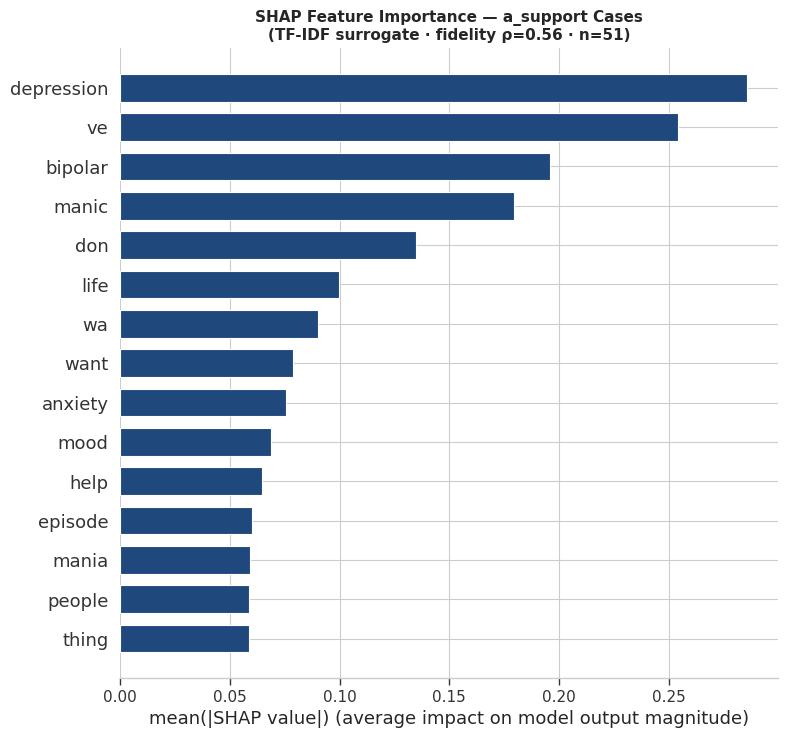

Saved → shap_support.pdf


In [19]:
print("Building TF-IDF surrogate for SHAP attribution ...")
vectorizer = TfidfVectorizer(
    max_features=800, stop_words="english", ngram_range=(1, 2), sublinear_tf=True
)
X_tr_tfidf = vectorizer.fit_transform(df_tr["text"].tolist())
X_te_tfidf = vectorizer.transform   (df_te["text"].tolist())

surrogate = LogisticRegression(max_iter=500, C=0.5, random_state=SEED)
surrogate.fit(X_tr_tfidf, y_tr)
surr_probs_te = surrogate.predict_proba(X_te_tfidf)[:, 1]

rho, p_rho = spearmanr(surr_probs_te, cal_probs_te)
print(f"Surrogate fidelity (Spearman ρ vs MentalBERT): {rho:.3f}  (p={p_rho:.2e})")
print("\nFidelity disclaimer: SHAP attributions explain the TF-IDF logistic surrogate,")
print("NOT the MentalBERT attention mechanism. Use for clinical scaffolding only.\n")

support_mask = res_pr["action"] == "a_support"
n_support    = int(support_mask.sum())
print(f"Cases routed to a_support: {n_support}")

if n_support > 0:
    X_sup = X_te_tfidf[support_mask][:100]   # cap for speed
    expl  = shap.LinearExplainer(surrogate, X_tr_tfidf,
                                  feature_perturbation="interventional")
    shap_v = expl.shap_values(X_sup)
    feat_names = vectorizer.get_feature_names_out()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    shap.summary_plot(
        shap_v, X_sup.toarray(), feature_names=feat_names,
        plot_type="bar", max_display=15, show=False, color=PALETTE["Threshold"],
    )
    ax.set_title(
        "SHAP Feature Importance — a_support Cases\n"
        f"(TF-IDF surrogate · fidelity ρ={rho:.2f} · n={n_support:,})",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("shap_support.pdf", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → shap_support.pdf")


## 14. Figures


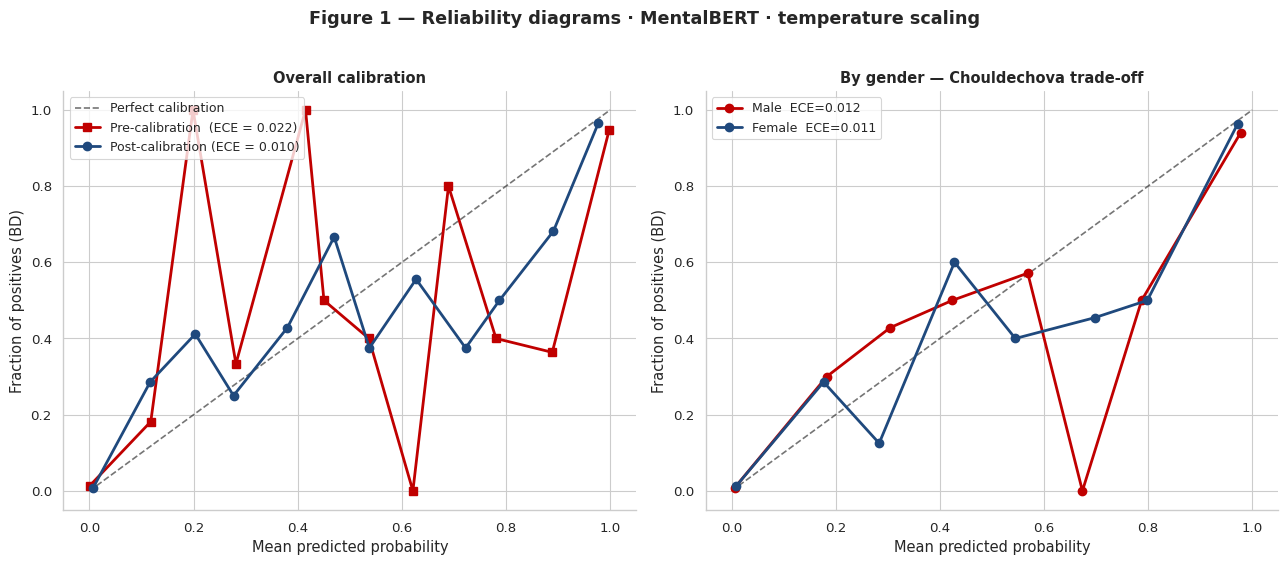

Saved → fig1_calibration.pdf


In [27]:
# --- Figure 1 — Reliability diagrams ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
fr_raw, mp_raw = calibration_curve(y_te, raw_probs_te, n_bins=12)
fr_cal, mp_cal = calibration_curve(y_te, cal_probs_te, n_bins=12)
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Perfect calibration")
ax.plot(mp_raw, fr_raw, "s-", color=C_MA, lw=2, ms=6,
        label=f"Pre-calibration  (ECE = {ece_score(raw_probs_te, y_te):.3f})")
ax.plot(mp_cal, fr_cal, "o-", color=C_TH, lw=2, ms=6,
        label=f"Post-calibration (ECE = {ece_score(cal_probs_te, y_te):.3f})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (BD)")
ax.set_title("Overall calibration", fontweight="bold")
ax.legend(fontsize=9); sns.despine(ax=ax)

ax = axes[1]
colors_g = {0: C_MA, 1: C_TH}
labels_g = {0: "Male", 1: "Female"}
ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6)
for g in (0, 1):
    m = gender_te == g
    fr, mp = calibration_curve(y_te[m], cal_probs_te[m], n_bins=8)
    ax.plot(mp, fr, "o-", color=colors_g[g], lw=2, ms=6,
            label=f"{labels_g[g]}  ECE={ece_score(cal_probs_te[m], y_te[m]):.3f}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (BD)")
ax.set_title("By gender — Chouldechova trade-off", fontweight="bold")
ax.legend(fontsize=9); sns.despine(ax=ax)

fig.suptitle("Figure 1 — Reliability diagrams · MentalBERT · temperature scaling",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_calibration.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig1_calibration.pdf")


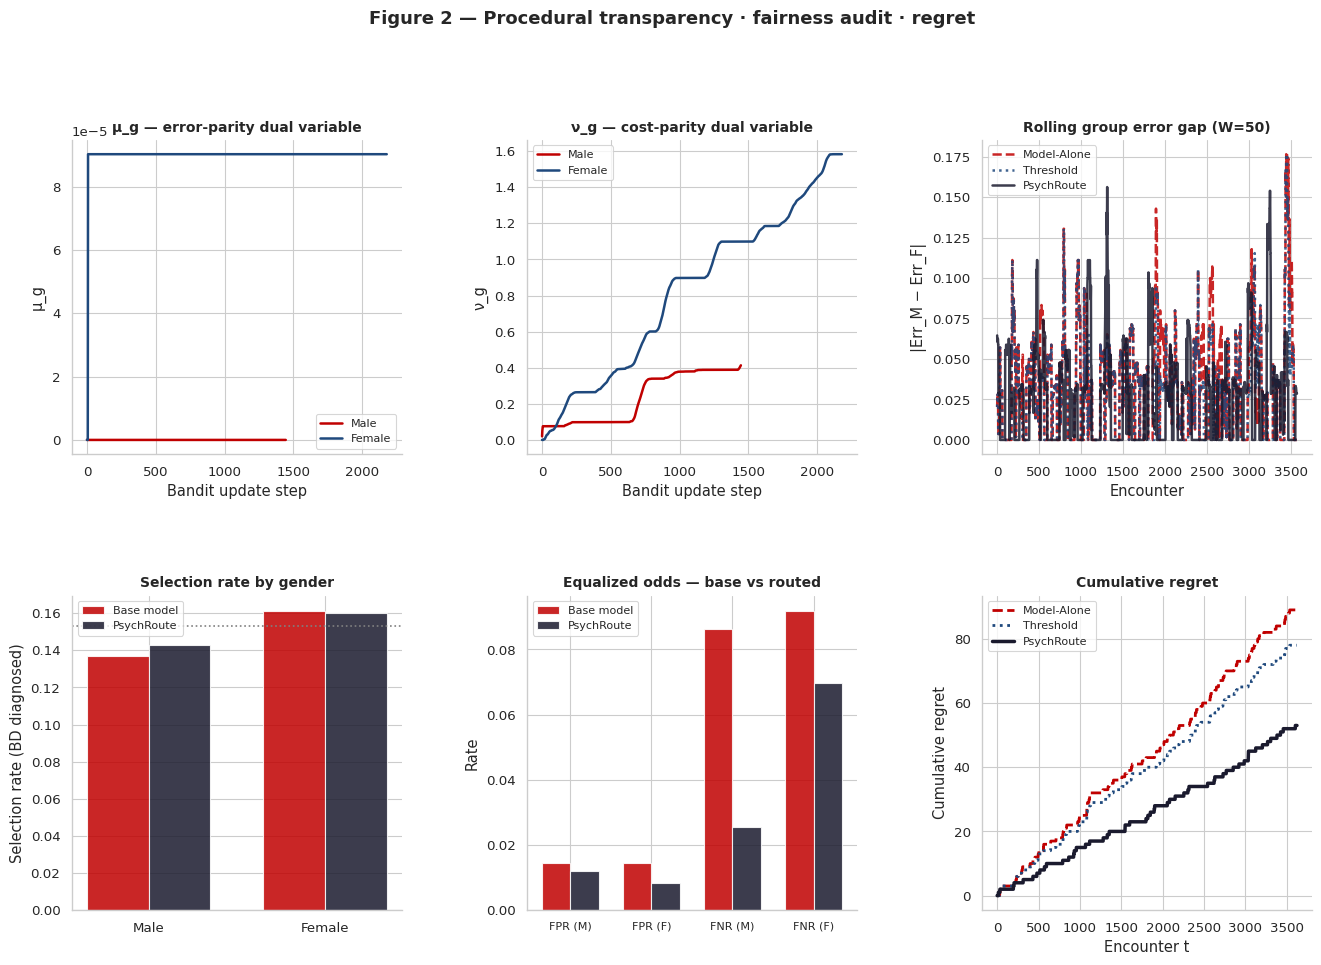

Saved → fig2_transparency.pdf


In [28]:
# --- Figure 2 — Procedural transparency, fairness audit, regret ------------
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38)

# 3A. mu_g evolution -------------------------------------------------------- #
ax = fig.add_subplot(gs[0, 0])
for g, lbl, col in [(0, "Male", C_MA), (1, "Female", C_TH)]:
    ax.plot(bandit_pr.log_mu[g], color=col, lw=1.8, label=lbl)
ax.set_title("μ_g — error-parity dual variable", fontweight="bold", fontsize=10)
ax.set_xlabel("Bandit update step")
ax.set_ylabel("μ_g")
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3B. nu_g evolution -------------------------------------------------------- #
ax = fig.add_subplot(gs[0, 1])
for g, lbl, col in [(0, "Male", C_MA), (1, "Female", C_TH)]:
    ax.plot(bandit_pr.log_nu[g], color=col, lw=1.8, label=lbl)
ax.set_title("ν_g — cost-parity dual variable", fontweight="bold", fontsize=10)
ax.set_xlabel("Bandit update step")
ax.set_ylabel("ν_g")
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3C. Rolling group error gap ----------------------------------------------- #
ax = fig.add_subplot(gs[0, 2])
W = 50
for nm, res, col, ls in [("Model-Alone", res_ma, C_MA, "--"),
                          ("Threshold",   res_th, C_TH, ":"),
                          ("PsychRoute",  res_pr, C_PR, "-")]:
    gaps = []
    for t in range(W, len(res["error"])):
        seg = slice(t - W, t)
        g0  = res["error"][seg][res["gender"][seg] == 0]
        g1  = res["error"][seg][res["gender"][seg] == 1]
        gaps.append(abs(g0.mean() - g1.mean()) if len(g0) and len(g1) else np.nan)
    ax.plot(np.arange(len(gaps)), gaps, color=col, lw=1.8, ls=ls,
            label=nm, alpha=0.85)
ax.set_title("Rolling group error gap (W=50)", fontweight="bold", fontsize=10)
ax.set_xlabel("Encounter")
ax.set_ylabel("|Err_M − Err_F|")
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3D. Selection rate by gender ---------------------------------------------- #
ax = fig.add_subplot(gs[1, 0])
sr_base = mf_base.by_group["selection_rate"]
sr_pr_g = mf_pr  .by_group["selection_rate"]
x_pos, w = np.arange(2), 0.35
ax.bar(x_pos - w/2, [sr_base.loc[0], sr_base.loc[1]], w,
       color=C_MA, alpha=0.85, label="Base model")
ax.bar(x_pos + w/2, [sr_pr_g.loc[0], sr_pr_g.loc[1]], w,
       color=C_PR, alpha=0.85, label="PsychRoute")
ax.axhline(y_te.mean(), color="gray", ls=":", lw=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(["Male", "Female"])
ax.set_ylabel("Selection rate (BD diagnosed)")
ax.set_title("Selection rate by gender", fontweight="bold", fontsize=10)
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3E. FPR / FNR by gender, base vs routed ---------------------------------- #
ax = fig.add_subplot(gs[1, 1])
metric_labels = ["FPR (M)", "FPR (F)", "FNR (M)", "FNR (F)"]
base_vals = [mf_base.by_group["false_positive_rate"].loc[0],
             mf_base.by_group["false_positive_rate"].loc[1],
             mf_base.by_group["false_negative_rate"].loc[0],
             mf_base.by_group["false_negative_rate"].loc[1]]
pr_vals   = [mf_pr.by_group["false_positive_rate"].loc[0],
             mf_pr.by_group["false_positive_rate"].loc[1],
             mf_pr.by_group["false_negative_rate"].loc[0],
             mf_pr.by_group["false_negative_rate"].loc[1]]
x_pos = np.arange(4)
ax.bar(x_pos - w/2, base_vals, w, color=C_MA, alpha=0.85, label="Base model")
ax.bar(x_pos + w/2, pr_vals,   w, color=C_PR, alpha=0.85, label="PsychRoute")
ax.set_xticks(x_pos); ax.set_xticklabels(metric_labels, fontsize=8)
ax.set_ylabel("Rate")
ax.set_title("Equalized odds — base vs routed", fontweight="bold", fontsize=10)
ax.legend(fontsize=8); sns.despine(ax=ax)

# 3F. Cumulative regret ----------------------------------------------------- #
ax = fig.add_subplot(gs[1, 2])
ax.plot(np.cumsum(res_ma["regret"]), color=C_MA, lw=2,   ls="--", label="Model-Alone")
ax.plot(np.cumsum(res_th["regret"]), color=C_TH, lw=2,   ls=":",  label="Threshold")
ax.plot(np.cumsum(res_pr["regret"]), color=C_PR, lw=2.5,          label="PsychRoute")
ax.set_xlabel("Encounter t"); ax.set_ylabel("Cumulative regret")
ax.set_title("Cumulative regret", fontweight="bold", fontsize=10)
ax.legend(fontsize=8); sns.despine(ax=ax)

fig.suptitle("Figure 2 — Procedural transparency · fairness audit · regret",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("fig2_transparency.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → fig2_transparency.pdf")
